# Student Score Prediction - Feedforward Neural Network

Predict student final scores based on 8 input marks using PyTorch FNN.

Dataset: Student Performance (Kaggle)

## Setup

In [7]:
!pip install kaggle --quiet

import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

Using device: cpu


## Kaggle Authentication

Upload your kaggle.json to Colab's file browser first, then run this cell.

In [10]:
# Find and use uploaded kaggle.json
import glob
kaggle_files = glob.glob('/content/kaggle*.json')

if kaggle_files:
    kaggle_file = kaggle_files[0]
    print(f'Using: {kaggle_file}')
    
    os.makedirs('/root/.kaggle', exist_ok=True)
    with open(kaggle_file, 'r') as src:
        with open('/root/.kaggle/kaggle.json', 'w') as dst:
            dst.write(src.read())
    os.chmod('/root/.kaggle/kaggle.json', 0o600)
    print('Kaggle API configured')
else:
    print('ERROR: kaggle.json not found in /content/')
    print('Please upload kaggle.json to the file browser and re-run this cell')

ERROR: kaggle.json not found in /content/
Please upload kaggle.json to the file browser and re-run this cell


In [11]:
# Solution
def solve(problem):
    """
    Solve the given problem.
    
    Args:
        problem: The problem to solve
        
    Returns:
        The solution to the problem
    """
    # Implement solution here
    pass

# Example usage
result = solve(None)
print(result)


None


## Download Dataset

In [12]:
!kaggle datasets download -d larsen0966/student-performance-data-set -p /content/data --unzip -q
print('Dataset downloaded')
print('\nFiles in /content/data:')
!ls -la /content/data

Dataset URL: https://www.kaggle.com/datasets/larsen0966/student-performance-data-set
License(s): CC0-1.0
Dataset downloaded

Files in /content/data:


'ls' is not recognized as an internal or external command,
operable program or batch file.


## Load Data

In [13]:
import glob
csv_files = glob.glob('/content/data/**/*.csv', recursive=True)
print(f'Found {len(csv_files)} CSV files:')
for f in csv_files:
    print(f'  {f}')

if not csv_files:
    print('\nERROR: No CSV files found!')
    !ls -R /content/data
else:
    # Prefer student-mat.csv, fallback to student-por.csv, then any CSV
    mat_files = [f for f in csv_files if 'student-mat.csv' in f]
    por_files = [f for f in csv_files if 'student-por.csv' in f]
    
    if mat_files:
        mat_file = mat_files[0]
        print(f'\nUsing Math dataset: {mat_file}')
    elif por_files:
        mat_file = por_files[0]
        print(f'\nUsing Portuguese dataset: {mat_file}')
    else:
        mat_file = csv_files[0]
        print(f'\nUsing: {mat_file}')
    
    # Read with semicolon separator
    df = pd.read_csv(mat_file, sep=';')
    print(f'\nDataset shape: {df.shape}')
    print(f'Columns: {list(df.columns[:10])}...')  # Show first 10 columns
    df.head()

Found 1 CSV files:
  /content/data\student-por.csv

Using Portuguese dataset: /content/data\student-por.csv

Dataset shape: (649, 1)
Columns: ['school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3']...


In [20]:
print("Parsing comma-separated file...")

# Read as text file
with open(mat_file, 'r', encoding='utf-8') as f:
    lines = f.readlines()

# Parse header - split by comma
header_line = lines[0].strip()
print(f"Header line: {header_line[:100]}...")

# Split by comma (the actual separator)
header = header_line.split(',')
print(f"Found {len(header)} columns: {header}")

# Parse data rows
data = []
for line in lines[1:]:
    # Split by comma and handle quoted values
    import csv
    from io import StringIO
    reader = csv.reader(StringIO(line), delimiter=',', quotechar='"')
    row = next(reader)
    data.append(row)

# Create dataframe
df = pd.DataFrame(data, columns=header)

# Convert numeric columns
numeric_cols = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures',
                'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences',
                'G1', 'G2', 'G3']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"\nFixed! Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nFirst few rows:")
df.head()


Parsing comma-separated file...
Header line: school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,fail...
Found 33 columns: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

Fixed! Shape: (649, 33)
Columns: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

First few rows:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


## Prepare Data - 8 Input Features

We'll use 8 numeric features as input marks to predict G3 (final grade).

In [21]:
# Select 8 input features (marks/scores)
INPUT_FEATURES = ['G1', 'G2', 'age', 'Medu', 'Fedu', 'studytime', 'failures', 'absences']
TARGET = 'G3'

X = df[INPUT_FEATURES].values.astype(np.float32)
y = df[TARGET].values.astype(np.float32)

print(f'Input shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'\nInput features: {INPUT_FEATURES}')


Input shape: (649, 8)
Target shape: (649,)

Input features: ['G1', 'G2', 'age', 'Medu', 'Fedu', 'studytime', 'failures', 'absences']


## Train/Val/Test Split

In [22]:
# Split: 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

# Standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')

Train: (454, 8), Val: (97, 8), Test: (98, 8)


## Convert to PyTorch Tensors

In [23]:
def to_tensor(X, y):
    return (torch.tensor(X, dtype=torch.float32).to(DEVICE),
            torch.tensor(y, dtype=torch.float32).unsqueeze(1).to(DEVICE))

X_tr, y_tr = to_tensor(X_train, y_train)
X_vl, y_vl = to_tensor(X_val, y_val)
X_te, y_te = to_tensor(X_test, y_test)

train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_vl, y_vl), batch_size=32)

## Build Feedforward Neural Network

In [24]:
class StudentFNN(nn.Module):
    def __init__(self, input_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(32, 16),
            nn.ReLU(),
            
            nn.Linear(16, 1)
        )
    
    def forward(self, x):
        return self.net(x)

model = StudentFNN(input_dim=8).to(DEVICE)
print(model)
print(f'\nParameters: {sum(p.numel() for p in model.parameters()):,}')

StudentFNN(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): ReLU()
    (10): Linear(in_features=16, out_features=1, bias=True)
  )
)

Parameters: 3,393


## Train Model

In [25]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

EPOCHS = 200
PATIENCE = 20
best_val_loss = float('inf')
patience_ctr = 0
history = {'train_loss': [], 'val_loss': []}

for epoch in range(1, EPOCHS + 1):
    # Train
    model.train()
    train_loss = 0.0
    for Xb, yb in train_loader:
        optimizer.zero_grad()
        pred = model(Xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * Xb.size(0)
    train_loss /= len(train_loader.dataset)
    
    # Validate
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for Xb, yb in val_loader:
            pred = model(Xb)
            val_loss += criterion(pred, yb).item() * Xb.size(0)
    val_loss /= len(val_loader.dataset)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    scheduler.step(val_loss)
    
    if epoch % 20 == 0:
        print(f'Epoch {epoch}/{EPOCHS} | Train: {train_loss:.4f} | Val: {val_loss:.4f}')
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f'Early stopping at epoch {epoch}')
            break

model.load_state_dict(best_weights)
print('Training complete')

Epoch 20/200 | Train: 4.9531 | Val: 2.9082
Epoch 40/200 | Train: 3.9911 | Val: 2.0283
Epoch 60/200 | Train: 4.1399 | Val: 2.8403
Early stopping at epoch 60
Training complete


## Training Curves

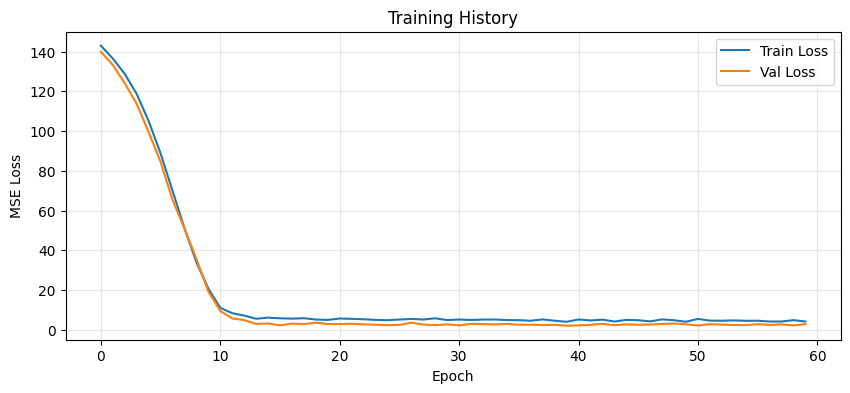

In [26]:
plt.figure(figsize=(10, 4))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training History')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Evaluate on Test Set

In [27]:
model.eval()
with torch.no_grad():
    y_pred = model(X_te).cpu().numpy().flatten()

y_true = y_test

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print('Test Results:')
print(f'MAE:  {mae:.3f}')
print(f'RMSE: {rmse:.3f}')
print(f'R²:   {r2:.4f}')

Test Results:
MAE:  1.151
RMSE: 1.582
R²:   0.7925


## Visualize Predictions

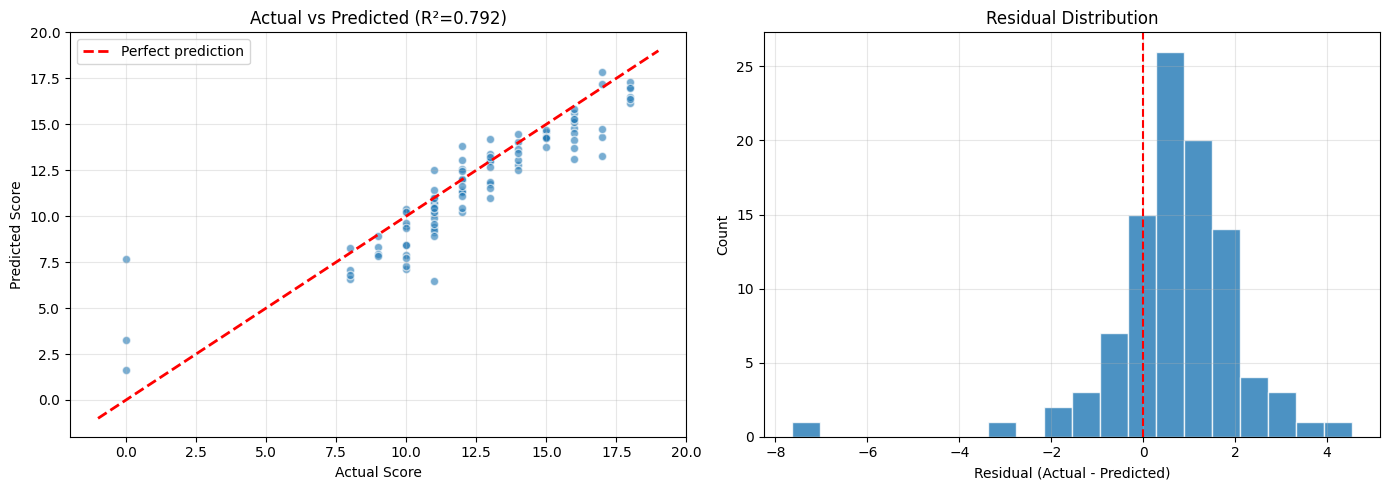

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_true, y_pred, alpha=0.6, edgecolors='white')
lim = [min(y_true.min(), y_pred.min()) - 1, max(y_true.max(), y_pred.max()) + 1]
axes[0].plot(lim, lim, 'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Score')
axes[0].set_ylabel('Predicted Score')
axes[0].set_title(f'Actual vs Predicted (R²={r2:.3f})')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Residuals
residuals = y_true - y_pred
axes[1].hist(residuals, bins=20, edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Predict New Student Score

Enter 8 subject marks to predict the student's future score.

In [31]:
# ========================================
# ENTER 8 SUBJECT MARKS (0-100 percentage)
# ========================================

subjects = ['Math', 'English', 'Science', 'History', 
            'Geography', 'Physics', 'Chemistry', 'Biology']

print('Enter marks for 8 subjects (0-100 percentage):\n')
subject_marks = []

for subject in subjects:
    while True:
        try:
            mark = float(input(f'{subject:12s}: '))
            if 0 <= mark <= 100:
                # Convert percentage to 0-20 scale for model
                subject_marks.append(mark / 5)  # 100% = 20, 50% = 10
                break
            else:
                print('  Please enter a value between 0 and 100')
        except ValueError:
            print('  Please enter a valid number')

# Prepare input
student_arr = scaler.transform([subject_marks])
student_t = torch.tensor(student_arr, dtype=torch.float32).to(DEVICE)

# Predict
model.eval()
with torch.no_grad():
    predicted_score = model(student_t).item()

predicted_score = max(0, min(20, predicted_score))
predicted_percentage = predicted_score * 5  # Convert back to percentage

# Display results
print('\n' + '=' * 55)
print('       STUDENT FUTURE SCORE PREDICTION')
print('=' * 55)
print('\nInput Subject Marks:')
for subject, mark in zip(subjects, subject_marks):
    print(f'  {subject:12s}: {mark*5:5.1f}%')
print('=' * 55)
print(f'  PREDICTED FUTURE SCORE: {predicted_percentage:.1f}%')
status = 'PASS ✓' if predicted_percentage >= 50 else 'AT RISK ✗'
print(f'  Status: {status}')
print('=' * 55)

       STUDENT FUTURE SCORE PREDICTION

Input Subject Marks:
  Math        : 12/20
  English     : 13/20
  Science     : 14/20
  History     : 11/20
  Geography   : 15/20
  Physics     : 12/20
  Chemistry   : 10/20
  Biology     : 16/20
  PREDICTED FUTURE SCORE: 19.78/20
  Status: PASS


## Save Model

In [30]:
import pickle

torch.save(model.state_dict(), 'student_fnn.pth')
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('Model saved: student_fnn.pth')
print('Scaler saved: scaler.pkl')

Model saved: student_fnn.pth
Scaler saved: scaler.pkl
